# 03 · Results and model decision

**Decision:** Keep feature engineering open and retain the lexical reference. A large executed search has exposed useful semantic signals and many negative findings. It has not established a final representation with independent confirmation.

In [1]:
import os
from pathlib import Path
import pandas as pd
from IPython.display import display
from jigsaw_rules.review import public_evidence
from jigsaw_rules.runtime import environment

root = Path(os.environ.get("JIGSAW_ROOT", Path.cwd())).resolve()
if root.name == "notebooks":
    root = root.parent
baseline = public_evidence(root, "baseline")
semantic = public_evidence(root, "semantic")
assert baseline["training_sha256"] == semantic["training_sha256"]
print("Competition evidence | 2,029 rows | two labeled rules")
print("Aggregate checksums verified. This notebook performs no model fitting.")
protocols = {"seen_rule": "Familiar rules", "heldout_rule": "Held-out rule"}

def metric_table(records, heldout=False):
    return pd.DataFrame([{"Representation": r["model"], "Validation": protocols[r["protocol"]],
        "Rule macro AUC": r["metrics"]["rule_macro_auc"],
        "Log loss": r["metrics"]["log_loss"], "Brier": r["metrics"]["brier"],
        "Average precision": r["metrics"]["average_precision"]}
        for r in records if not heldout or r["protocol"] == "heldout_rule"]).round(4)


Competition evidence | 2,029 rows | two labeled rules
Aggregate checksums verified. This notebook performs no model fitting.


In [2]:
import sys
sys.path.insert(0, str(root / "scripts"))
from build_research_report import display_figure
from jigsaw_rules.features import feature_evidence
from jigsaw_rules.research import research_evidence
from jigsaw_rules.diagnostics import diagnostic_evidence
from jigsaw_rules.pairs import pairs_evidence
from jigsaw_rules.robustness import robustness_evidence
from jigsaw_rules.gate import feature_gate
from jigsaw_rules.instructions import instruction_evidence

controls = feature_evidence(root)
research = research_evidence(root)
sensitivity = diagnostic_evidence(root)
pairs = pairs_evidence(root)
robustness = robustness_evidence(root)
assert all(item is not None for item in (controls, research, sensitivity, pairs, robustness))
gate = feature_gate(root)
instructions = instruction_evidence(root)
print("Verified research runs:", gate["studies"])


Verified research runs: {'research': '9ec008d506b0bc64a717', 'sensitivity': 'bce07fd60bc7543fca49', 'pairs': '537cf2213c813b8ebd4b', 'robustness': 'a09455ec14e9b3d6ab61', 'instructions': '96bf69f42f9063e01a12'}


## Compare representations on identical held-out rows
These are local rule-macro AUC results, not leaderboard scores. The same fixed classifier is used for learned feature probes. Frozen scores require no competition-label fitting. Probability losses remain visible alongside ranking.

In [3]:
records = [r for r in baseline["results"] if r["model"] == "rule_examples"]
records += [r for r in research["results"] if r["model"] in ["word_screened", "word_semantic_scalar", "all_transfer", "all_with_metadata"]]
records += [r for r in sensitivity["results"] if r["model"] in ["qwen_centroid", "character_full", "word_character_nb"]]
records += pairs["results"]
if instructions is not None:
    records += instructions["results"]
display(metric_table(records, heldout=True).sort_values("Rule macro AUC", ascending=False))

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
6,qwen_centroid,Held-out rule,0.6416,0.6693,0.2385,0.6228
5,character_full,Held-out rule,0.6235,0.6646,0.2361,0.6200
2,word_semantic_scalar,Held-out rule,0.6217,0.7248,0.2604,0.6010
0,rule_examples,Held-out rule,0.6156,0.6736,0.2405,0.6241
7,word_character_nb,Held-out rule,0.6076,0.6753,0.2406,0.5900
11,word_nli,Held-out rule,0.5964,0.6964,0.2475,0.6097
1,word_screened,Held-out rule,0.5893,0.6782,0.2421,0.5993
19,word_instruction,Held-out rule,0.5755,0.6958,0.2495,0.5850
18,semantic_instruction,Held-out rule,0.5716,0.7812,0.2869,0.5335
10,all_nli,Held-out rule,0.5602,0.7252,0.2631,0.5475


## What the feature work established
Compact semantic relationships and character patterns deserve more attention than high-dimensional structural expansion or raw coordinate selection. Target/context and community features have not justified their availability and transfer risks. Unscreened controls are essential: screening reduces size but can also remove useful signal.

See [02 · Feature research](02_baseline_and_review.ipynb) for candidate counts, matched additions/removals, simultaneous intervals, stability, negative findings and the feature catalog.

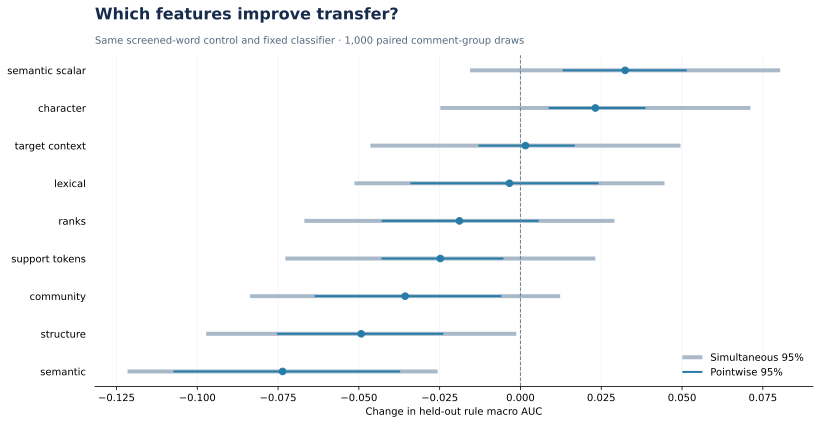

In [4]:
display_figure(root, "ablation")

## Promotion and artifact lineage
The notebooks consume the latest verified research aggregates. The offline submission path still fits the explicitly named original lexical reference. No final candidate has been selected, no novel feature artifact has been promoted, and no CSV has been submitted to Kaggle. This is a deliberate open gate, not stale-model reuse disguised as a new result.

In [5]:
display(pd.DataFrame(gate["criteria"]))
print("Gate:", gate["status"])
print(gate["decision"])

,requirement,state
0,Broad candidate generation and training-only s...,verified
1,"Matched additions, removals, permutation and s...",verified
2,Unscreened controls and support-geometry alter...,verified
3,Joint comment-rule and support entailment repr...,verified
4,Self-support and approximate-copy stress tests,verified
5,Fixed instruction-likelihood and context ablat...,verified
6,Independent confirmation after feature-family ...,not established
7,Representative coverage of unseen policy types,not established
8,Selected final representation and probability-...,not established
9,Research candidate promoted into offline infer...,blocked until prior requirements pass


Gate: open
Retain the reproducible lexical reference. Candidate OOF comparisons are exploratory; repeated selection on two policies is not independent confirmation. Feature count and successful execution do not close this gate.


## Remaining uncertainty
Two labeled policies cannot establish broad unseen-rule generalization. Repeatedly inspecting the same held-out scores also creates selection bias; within-study simultaneous intervals only address part of that problem. Calibration, final representation selection and final retraining remain downstream of the feature gate.

[04 · Semantic diagnostics](04_semantic_benchmark.ipynb) examines policy-level behavior and probability quality. The [research record](../docs/FEATURE_RESEARCH.md) describes which high-value avenues were explored, ruled inapplicable, or remain unresolved.